genera datos sintéticos de retorno, ratio P/E y capitalización de mercado, demostrando cómo la inclusión de múltiples variables aísla los coeficientes de regresión parcial y corrige las interpretaciones erróneas de magnitud versus escala 

In [ ]:
#aaaaaaaaaaaaaaaaaaallllllllllllllllllllllllllllllllllllaaaaaaaaaaaaaaaaaaaaaaaaaa

--- 1. DEMOSTRACIÓN DEL SESGO DE VARIABLE OMITIDA ---
Coeficiente Beta_1 (Regresión Simple - Omitiendo X2): 0.4298
Nota cómo el signo cambia a POSITIVO porque absorbe el efecto 'fantasma' de Market Cap.

--- 2. MODELO DE REGRESIÓN MÚLTIPLE (EFECTO CETERIS PARIBUS) ---
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.4994      0.221     15.850      0.000       3.064       3.935
PE_Ratio      -0.1059      0.007    -14.550      0.000      -0.120      -0.092
Market_Cap     0.0365      0.000     98.773      0.000       0.036       0.037

Interpretación Pura (Ceteris Paribus):
Manteniendo la Capitalización constante, 1 unidad más de P/E disminuye el retorno en 0.1059%.

--- 3. TRAMPA DE LA MAGNITUD VS IMPORTANCIA (ESCALA) ---
A simple vista, 0.0368 (Market_Cap) parece menor que 0.114 (PE_Ratio).
Pero Market_Cap se mide en millones. Veamos el impacto de un cambio de 1 

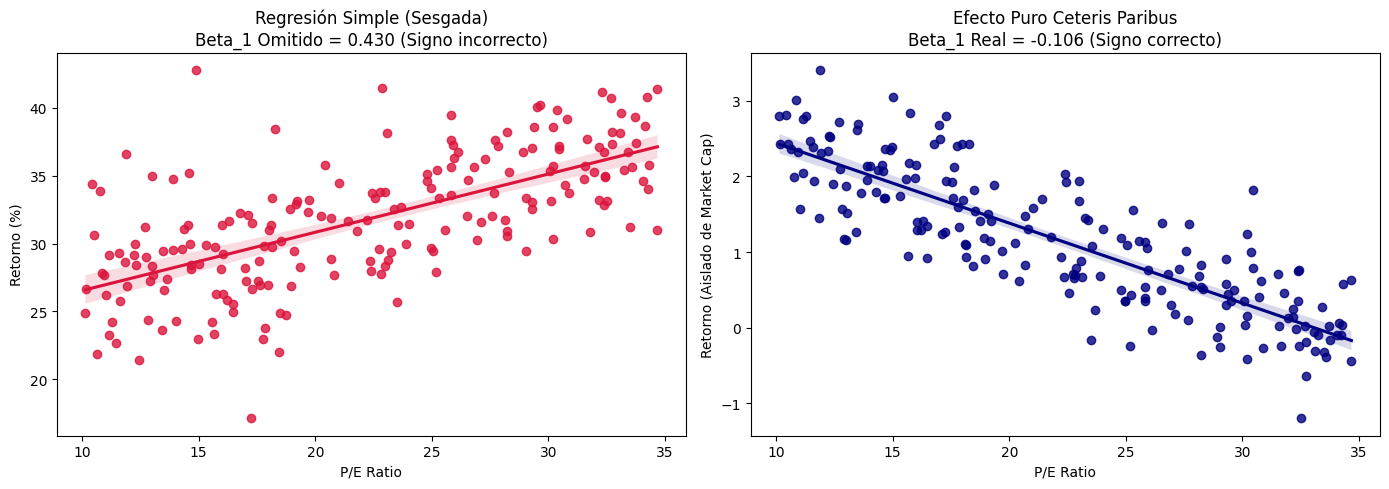

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuración de semilla para replicabilidad
np.random.seed(42)
n_samples = 200

# 2. Generación de Datos Simulados (Caso Real de Finanzas)
# X1: P/E Ratio (Rango típico entre 10 y 35)
X1 = np.random.uniform(10, 35, n_samples)

# X2: Market Cap en millones de dólares (Supongamos cierta correlación natural con P/E)
# Añadimos ruido para que no sea una relación perfecta
X2 = X1 * 15 + np.random.normal(500, 100, n_samples) 

# El proceso generador de datos real (basado en tus coeficientes teóricos)
# Y = 3.432 - 0.114*X1 + 0.0368*X2 + Error
Error = np.random.normal(0, 0.5, n_samples)
Y = 3.432 - 0.114 * X1 + 0.0368 * X2 + Error

# Crear el DataFrame de Pandas
df = pd.DataFrame({'Retorno': Y, 'PE_Ratio': X1, 'Market_Cap': X2})

print("--- 1. DEMOSTRACIÓN DEL SESGO DE VARIABLE OMITIDA ---")
# Regresión Lineal Simple (Omitiendo Market_Cap)
X_simple = sm.add_constant(df['PE_Ratio'])
modelo_simple = sm.OLS(df['Retorno'], X_simple).fit()
print(f"Coeficiente Beta_1 (Regresión Simple - Omitiendo X2): {modelo_simple.params['PE_Ratio']:.4f}")
print("Nota cómo el signo cambia a POSITIVO porque absorbe el efecto 'fantasma' de Market Cap.\n")

# Regresión Lineal Múltiple (Modelo Completo)
X_multiple = sm.add_constant(df[['PE_Ratio', 'Market_Cap']])
modelo_multiple = sm.OLS(df['Retorno'], X_multiple).fit()
print("--- 2. MODELO DE REGRESIÓN MÚLTIPLE (EFECTO CETERIS PARIBUS) ---")
print(modelo_multiple.summary().tables[1])
print(f"\nInterpretación Pura (Ceteris Paribus):")
print(f"Manteniendo la Capitalización constante, 1 unidad más de P/E disminuye el retorno en {abs(modelo_multiple.params['PE_Ratio']):.4f}%.")

print("\n--- 3. TRAMPA DE LA MAGNITUD VS IMPORTANCIA (ESCALA) ---")
print("A simple vista, 0.0368 (Market_Cap) parece menor que 0.114 (PE_Ratio).")
print("Pero Market_Cap se mide en millones. Veamos el impacto de un cambio de 1 desviación estándar:")
std_pe = df['PE_Ratio'].std()
std_mc = df['Market_Cap'].std()
print(f"Impacto de 1 Desviación Estándar en P/E ({std_pe:.2f} unidades): {modelo_multiple.params['PE_Ratio'] * std_pe:.4f}%")
print(f"Impacto de 1 Desviación Estándar en Market Cap ({std_mc:.2f} millones): {modelo_multiple.params['Market_Cap'] * std_mc:.4f}%")

# 4. Visualización Gráfica del Experimento Estadístico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: El espejismo de la regresión simple
sns.regplot(ax=axes[0], x='PE_Ratio', y='Retorno', data=df, color='crimson')
axes[0].set_title(f"Regresión Simple (Sesgada)\nBeta_1 Omitido = {modelo_simple.params['PE_Ratio']:.3f} (Signo incorrecto)")
axes[0].set_xlabel("P/E Ratio")
axes[0].set_ylabel("Retorno (%)")

# Gráfico 2: Aislando el efecto (Ceteris Paribus) de manera visual
# Graficamos el Retorno limpio del efecto de Market Cap
df['Retorno_Limpio_X2'] = df['Retorno'] - (modelo_multiple.params['Market_Cap'] * df['Market_Cap'])
sns.regplot(ax=axes[1], x='PE_Ratio', y='Retorno_Limpio_X2', data=df, color='navy')
axes[1].set_title(f"Efecto Puro Ceteris Paribus\nBeta_1 Real = {modelo_multiple.params['PE_Ratio']:.3f} (Signo correcto)")
axes[1].set_xlabel("P/E Ratio")
axes[1].set_ylabel("Retorno (Aislado de Market Cap)")

plt.tight_layout()
plt.show()
